In [2]:
# Maybe also look at changes to the proportion of events falling onto soils with different properties?

In [3]:
import os
import sys
import re
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf

from Functions_AnalyseResults import partial_r2_for_catchment, plot_with_best_fit_line

sys.path.append('../ProcessEvents/')
from config import CATCHMENT_LOOKUP_DICT, OUT_DIR # MOLLY_DIR_FF, RAINFALL_CSV_DIR, ENSEMBLE_MEMBERS, , CATCHMENTS

## Get a list of catchments which have flood outputs and rainfall detail outputs

In [4]:
all_catchments = set(CATCHMENT_LOOKUP_DICT.keys())

catchments_with_flood_output = []
for catchment_num in all_catchments:
    catchment_name = CATCHMENT_LOOKUP_DICT[catchment_num]
    fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/Catchment_{catchment_num}/{catchment_name}.pkl"
    flood_fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/PluvialResults/5km_total/Catchment_{catchment_num}/Ens01_{catchment_num}/10cm/flooded_area_5km_total_Ens01_{catchment_num}_10cm.nc"
        
    if os.path.isfile(flood_fp) and os.path.isfile(fp):
        catchments_with_flood_output.append(catchment_num)
print(len(catchments_with_flood_output))

113


### Join together results for all these catchments, remove mismatched rows, add a catchment number flag

In [5]:
rainfall_events_all = []
for catchment_num in catchments_with_flood_output:
    catchment_name = CATCHMENT_LOOKUP_DICT[catchment_num]
    fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/Catchment_{catchment_num}/{catchment_name}.pkl"
    rainfall_events = pd.read_pickle(fp)
    rainfall_events_complete = rainfall_events[rainfall_events['mismatch']!=True].copy()
    rainfall_events['catchment_num'] = catchment_num
    # print(f"Catchment {catchment_num} has {len(rainfall_events)}, of which {len(rainfall_events) - len(rainfall_events_complete)} are mismatched")
    rainfall_events_all.append(rainfall_events) 
rainfall_events_all_df = pd.concat(rainfall_events_all, ignore_index=True)    

In [6]:
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['max_precip']<130].copy()

</div>

<div style="background-color: #f0faf0; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Getting spatial data

</div>

In [7]:
regions_shp = "/scratch/hydro5/users/la17355/FUTURE-FLOOD/Results/Pluvial/v4/#ss/plots/most_exposed_events_visualisation/by_region/ukcp18-uk-land-region-hires.shp"
regions_df = gpd.read_file(regions_shp)

In [8]:
rainfall_events_all_df = gpd.GeoDataFrame(rainfall_events_all_df, geometry=gpd.points_from_xy(rainfall_events_all_df['x_coord'],
                                                                                              rainfall_events_all_df['y_coord']), crs=regions_df.crs)
rainfall_events_all_df = gpd.sjoin(rainfall_events_all_df, regions_df[['geometry', 'geo_region']], how='left', predicate='within')

### Add variable describing length of event

In [9]:
rainfall_events_all_df['length'] = rainfall_events_all_df['times'].apply(len)

### Add variable classifying based on HC value

In [10]:
rainfall_events_all_df['HC_status'] = pd.cut(rainfall_events_all_df['hc_at_peak'],
    bins=[-float('inf'), 0.15, 1.1, 3, float('inf')],labels=['D', 'C', 'B', 'A'], right=False, include_lowest=True)

In [22]:
rainfall_events_all_df['HC_status_2'] = pd.cut(rainfall_events_all_df['hc_at_peak'],
    bins=[-float('inf'), 0.15, 0.3, 0.6, 1, 2, 3, float('inf')],labels=['G', 'F', 'E', 'D', 'C', 'B', 'A'], right=False,
                                               include_lowest=True)

# rainfall_events_all_df['HC_status_2'] = pd.cut(rainfall_events_all_df['hc_at_peak'],
#     bins=[-float('inf'), 0.1, 0.15, 0.3, 0.6, 1,  3, float('inf')],labels=['G', 'F', 'E', 'D', 'C', 'B', 'A'], right=False,
#                                                include_lowest=True)

In [12]:
### SEPARATE EVENTS WHICH IN URBAN AREAS

</div>

<div style="background-color: #f0faf0; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Look at correlations:
Between flooding and rainfall intensity/accumulation/soil moisture

</div>

In [20]:
# Quick sanity check: distribution of predictors and target per HC class
df = rainfall_events_all_df.copy()
# print(df.groupby('HC_status')[['max_precip', 'total_acc', 'mean_sm_2_before_event', '10cm_area']].describe())

# Simple correlation matrix per class - first look at which predictor tracks flood_metric best, by class
for cls in sorted(df['HC_status'].unique()):
    sub = df[df['HC_status'] == cls]
    corrs = sub[['max_precip', 'total_acc', 'mean_sm_2_before_event', '10cm_area']].corr()['10cm_area']
    print(f"\nHC class {cls} (n={len(sub)}):")
    print(corrs)


HC class A (n=2556):
max_precip                0.768905
total_acc                 0.296795
mean_sm_2_before_event    0.078492
10cm_area                 1.000000
Name: 10cm_area, dtype: float64

HC class B (n=10688):
max_precip                0.762574
total_acc                 0.540516
mean_sm_2_before_event    0.121427
10cm_area                 1.000000
Name: 10cm_area, dtype: float64

HC class C (n=74955):
max_precip                0.380370
total_acc                 0.261916
mean_sm_2_before_event   -0.109872
10cm_area                 1.000000
Name: 10cm_area, dtype: float64

HC class D (n=13847):
max_precip                0.438166
total_acc                 0.469903
mean_sm_2_before_event   -0.017852
10cm_area                 1.000000
Name: 10cm_area, dtype: float64


</div>

<div style="background-color: #f0faf0; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Run OLS regression:
Between flooding and rainfall intensity/accumulation variables.  
Look at how performance is improved by adding other variables

</div>

In [16]:
intensity_vars = ['max_precip', 'total_acc']
shape_vars = ['peak_position_ratio', 'd50', 'gini', 'time_based_std', 'dry_ratio', 'max_quartile_index']
neighbourhood_vars = ['neighbourhood_rain_sum_excl_peak']
antecedent_vars = ['mean_sm_2_before_event']
length_vars = ['length']
candidate_vars = length_vars + antecedent_vars + neighbourhood_vars + shape_vars + intensity_vars

In [24]:
len(df)

102046

In [23]:
df = rainfall_events_all_df.copy()
def run_stage(sub, predictors, label):
    formula = 'Q("10cm_area") ~ ' + ' + '.join(predictors)
    model = smf.ols(formula, data=sub).fit()
    # print(model.summary())
    print(f"  {label}: R² = {model.rsquared:.3f}")
    return model

results = {}
for cls in sorted(df['HC_status_2'].unique()):
    sub = df[df['HC_status_2'] == cls].dropna(subset=candidate_vars + ['10cm_area'])
    print(f"\n--- HC class {cls} (n={len(sub)}) ---")
    
    m1 = run_stage(sub, intensity_vars + antecedent_vars, "Baseline (intensity+acc+antecedent)")
    m2 = run_stage(sub, intensity_vars + antecedent_vars + shape_vars, "+ shape/temporal-loading")
    m3 = run_stage(sub, intensity_vars + antecedent_vars + shape_vars + neighbourhood_vars, "+ neighbourhood")
    m4 = run_stage(sub, intensity_vars + antecedent_vars + shape_vars + neighbourhood_vars + length_vars, "+ length")
    
    results[cls] = {'baseline': m1, 'shape': m2, 'length': m3, 'full': m4}


--- HC class A (n=2556) ---
  Baseline (intensity+acc+antecedent): R² = 0.600
  + shape/temporal-loading: R² = 0.606
  + neighbourhood: R² = 0.606
  + length: R² = 0.608

--- HC class B (n=5433) ---
  Baseline (intensity+acc+antecedent): R² = 0.684
  + shape/temporal-loading: R² = 0.695
  + neighbourhood: R² = 0.697
  + length: R² = 0.697

--- HC class C (n=21917) ---
  Baseline (intensity+acc+antecedent): R² = 0.527
  + shape/temporal-loading: R² = 0.558
  + neighbourhood: R² = 0.565
  + length: R² = 0.566

--- HC class D (n=6702) ---
  Baseline (intensity+acc+antecedent): R² = 0.368
  + shape/temporal-loading: R² = 0.413
  + neighbourhood: R² = 0.440
  + length: R² = 0.444

--- HC class E (n=36392) ---
  Baseline (intensity+acc+antecedent): R² = 0.229
  + shape/temporal-loading: R² = 0.241
  + neighbourhood: R² = 0.264
  + length: R² = 0.265

--- HC class F (n=15186) ---
  Baseline (intensity+acc+antecedent): R² = 0.256
  + shape/temporal-loading: R² = 0.263
  + neighbourhood: R² = 

In [26]:
def run_stage(sub, predictors, label):
    formula = 'Q("10cm_area") ~ ' + ' + '.join(predictors)
    model = smf.ols(formula, data=sub).fit()
    # print(model.summary())
    print(f"  {label}: R² = {model.rsquared:.3f}")
    return model

results = {}
for cls in sorted(df['HC_status_2'].unique()):
    sub = df[df['HC_status_2'] == cls].dropna(subset=candidate_vars + ['10cm_area'])
    print(f"\n--- HC class {cls} (n={len(sub)}) ---")
    
    m1 = run_stage(sub, intensity_vars + antecedent_vars, "Baseline (intensity+acc+antecedent)")
    m2 = run_stage(sub, intensity_vars + antecedent_vars + shape_vars, "+ shape/temporal-loading")
    m3 = run_stage(sub, intensity_vars + antecedent_vars + shape_vars + neighbourhood_vars, "+ neighbourhood")
    m4 = run_stage(sub, intensity_vars + antecedent_vars + shape_vars + neighbourhood_vars + length_vars, "+ length")
    
    results[cls] = {'baseline': m1, 'shape': m2, 'length': m3, 'full': m4}


--- HC class A (n=2556) ---
  Baseline (intensity+acc+antecedent): R² = 0.600
  + shape/temporal-loading: R² = 0.606
  + neighbourhood: R² = 0.606
  + length: R² = 0.608

--- HC class B (n=10685) ---
  Baseline (intensity+acc+antecedent): R² = 0.611
  + shape/temporal-loading: R² = 0.628
  + neighbourhood: R² = 0.629
  + length: R² = 0.629

--- HC class C (n=74945) ---
  Baseline (intensity+acc+antecedent): R² = 0.181
  + shape/temporal-loading: R² = 0.191
  + neighbourhood: R² = 0.237
  + length: R² = 0.237

--- HC class D (n=13847) ---
  Baseline (intensity+acc+antecedent): R² = 0.260
  + shape/temporal-loading: R² = 0.267
  + neighbourhood: R² = 0.297
  + length: R² = 0.297


In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

for cls in sorted(df['HC_status_new'].unique())[3:]:
    sub = df[df['HC_status_new'] == cls].dropna(subset=candidate_vars + ['10cm_area'])
    print(len(sub))
    sub = sub[sub['10cm_area']>0]
    print(len(sub))
    X = sub[candidate_vars]
    y = sub['10cm_area']
    rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=0, n_jobs=-1)
    scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
    print(f"{cls}: RF CV R² = {scores.mean():.3f} (+/- {scores.std():.3f})")

15186
15186
E: RF CV R² = 0.229 (+/- 0.054)
59759
58016
F: RF CV R² = 0.314 (+/- 0.023)


In [21]:
sub = df[df['HC_status'] == 'C']

mid_val = (sub['hc_at_peak'].min() + sub['hc_at_peak'].max()) / 2
mid_val = 0.4

df['HC_status_new'] = df['HC_status']
df['HC_status_new'] = df['HC_status'].astype(str)

mask = df['HC_status'] == 'C'

df.loc[mask & (df['hc_at_peak'] <= mid_val), 'HC_status_new'] = 'E'
df.loc[mask & (df['hc_at_peak'] >  mid_val), 'HC_status_new'] = 'F'

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

for cls in sorted(df['HC_status_new'].unique())[3:]:
    sub = df[df['HC_status_new'] == cls].dropna(subset=candidate_vars + ['10cm_area'])
    print(len(sub))
    sub = sub[sub['10cm_area']>0]
    print(len(sub))
    X = sub[candidate_vars]
    y = sub['10cm_area']
    rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=0, n_jobs=-1)
    scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
    print(f"{cls}: RF CV R² = {scores.mean():.3f} (+/- {scores.std():.3f})")

41441
41441
E: RF CV R² = 0.176 (+/- 0.032)
33504
31761
F: RF CV R² = 0.416 (+/- 0.040)


In [23]:
sub = df[df['HC_status'] == 'C']

mid_val = (sub['hc_at_peak'].min() + sub['hc_at_peak'].max()) / 2
mid_val = 0.5

df['HC_status_new'] = df['HC_status']
df['HC_status_new'] = df['HC_status'].astype(str)

mask = df['HC_status'] == 'C'

df.loc[mask & (df['hc_at_peak'] <= mid_val), 'HC_status_new'] = 'E'
df.loc[mask & (df['hc_at_peak'] >  mid_val), 'HC_status_new'] = 'F'

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

for cls in sorted(df['HC_status_new'].unique())[3:]:
    sub = df[df['HC_status_new'] == cls].dropna(subset=candidate_vars + ['10cm_area'])
    print(len(sub))
    sub = sub[sub['10cm_area']>0]
    print(len(sub))
    X = sub[candidate_vars]
    y = sub['10cm_area']
    rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=0, n_jobs=-1)
    scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
    print(f"{cls}: RF CV R² = {scores.mean():.3f} (+/- {scores.std():.3f})")

48276
48276
E: RF CV R² = 0.164 (+/- 0.034)
26669
24926
F: RF CV R² = 0.451 (+/- 0.049)


In [27]:
sub = df[df['HC_status'] == 'C']

mid_val = (sub['hc_at_peak'].min() + sub['hc_at_peak'].max()) / 2
mid_val = 0.8

df['HC_status_new'] = df['HC_status']
df['HC_status_new'] = df['HC_status'].astype(str)

mask = df['HC_status'] == 'C'

df.loc[mask & (df['hc_at_peak'] <= mid_val), 'HC_status_new'] = 'E'
df.loc[mask & (df['hc_at_peak'] >  mid_val), 'HC_status_new'] = 'F'

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

for cls in sorted(df['HC_status_new'].unique())[3:]:
    sub = df[df['HC_status_new'] == cls].dropna(subset=candidate_vars + ['10cm_area'])
    print(len(sub))
    sub = sub[sub['10cm_area']>0]
    print(len(sub))
    X = sub[candidate_vars]
    y = sub['10cm_area']
    rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=0, n_jobs=-1)
    scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
    print(f"{cls}: RF CV R² = {scores.mean():.3f} (+/- {scores.std():.3f})")

55160
55120
E: RF CV R² = 0.203 (+/- 0.031)
19785
18082
F: RF CV R² = 0.513 (+/- 0.050)


In [36]:
sub = df[df['HC_status'] == 'C']

mid_val = (sub['hc_at_peak'].min() + sub['hc_at_peak'].max()) / 2
mid_val = 1.1

df['HC_status_new'] = df['HC_status']
df['HC_status_new'] = df['HC_status'].astype(str)

mask = df['HC_status'] == 'C'

df.loc[mask & (df['hc_at_peak'] <= mid_val), 'HC_status_new'] = 'E'
df.loc[mask & (df['hc_at_peak'] >  mid_val), 'HC_status_new'] = 'F'

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

for cls in sorted(df['HC_status_new'].unique())[3:]:
    sub = df[df['HC_status_new'] == cls].dropna(subset=candidate_vars + ['10cm_area'])
    print(len(sub))
    sub = sub[sub['10cm_area']>0]
    print(len(sub))
    X = sub[candidate_vars]
    y = sub['10cm_area']
    rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=0, n_jobs=-1)
    scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
    print(f"{cls}: RF CV R² = {scores.mean():.3f} (+/- {scores.std():.3f})")

74945
73202
E: RF CV R² = 0.237 (+/- 0.039)


In [28]:
sub = df[df['HC_status'] == 'C']

mid_val = (sub['hc_at_peak'].min() + sub['hc_at_peak'].max()) / 2
mid_val = 1.0

df['HC_status_new'] = df['HC_status']
df['HC_status_new'] = df['HC_status'].astype(str)

mask = df['HC_status'] == 'C'

df.loc[mask & (df['hc_at_peak'] <= mid_val), 'HC_status_new'] = 'E'
df.loc[mask & (df['hc_at_peak'] >  mid_val), 'HC_status_new'] = 'F'

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

for cls in sorted(df['HC_status_new'].unique())[3:]:
    sub = df[df['HC_status_new'] == cls].dropna(subset=candidate_vars + ['10cm_area'])
    print(len(sub))
    sub = sub[sub['10cm_area']>0]
    print(len(sub))
    X = sub[candidate_vars]
    y = sub['10cm_area']
    rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=0, n_jobs=-1)
    scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
    print(f"{cls}: RF CV R² = {scores.mean():.3f} (+/- {scores.std():.3f})")

58280
58224
E: RF CV R² = 0.218 (+/- 0.023)
16665
14978
F: RF CV R² = 0.527 (+/- 0.048)


In [39]:
predictor_variable = '10cm_area'
explainer_variables = rainfall_events_all_df.columns
stuff = {'t_global', 't_local', 'mismatch', 'hydro_day_360', 'rainfall_peak_day', 'values', 'times',
        "max_precip_from_csv", "t_local_rebased", "start_idx", "stop_idx", "time_mismatch", "HC_status", "catchment_num"}
flood_output_vars = { '10cm_area', '10cm_volume',  '30cm_area', '30cm_volume', 'neighbourhood_flood_10_area',
                     'neighbourhood_flood_10_vol', 'neighbourhood_flood_30_area', 'neighbourhood_flood_30_vol',
                    'threshold_flood_10_area_t50', 'cluster_flood_10_area_t50', 'threshold_flood_10_vol_t50',
 'cluster_flood_10_vol_t50', 'threshold_flood_30_area_t50', 'cluster_flood_30_area_t50', 'threshold_flood_30_vol_t50',
 'cluster_flood_30_vol_t50', 'threshold_flood_10_area_t60', 'cluster_flood_10_area_t60', 'threshold_flood_10_vol_t60',
 'cluster_flood_10_vol_t60', 'threshold_flood_30_area_t60',  'cluster_flood_30_area_t60',  'threshold_flood_30_vol_t60',
 'cluster_flood_30_vol_t60', 'threshold_flood_10_area_t80', 'cluster_flood_10_area_t80', 'threshold_flood_10_vol_t80', 
'cluster_flood_10_vol_t80', 'threshold_flood_30_area_t80', 'cluster_flood_30_area_t80', 'threshold_flood_30_vol_t80',
                     'cluster_flood_30_vol_t80' }
spatial_vars = {'y_idx', 'y_idx_global', 'y_coord', 'x_coord', 'x_idx', 'x_idx_global'}
explainer_variables = [item for item in explainer_variables if item not in stuff and item not in flood_output_vars
                       and item not in spatial_vars]

In [40]:
sub = rainfall_events_all_df[rainfall_events_all_df['HC_status'] == 'D']

# Split data into train/test
X_train, X_test, y_train, y_test = train_test_split(sub[explainer_variables], 
                                                    sub[predictor_variable], 
                                                    test_size=0.2, random_state=42)

# Fit Random Forest
rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Model performance
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))

R²: 0.7743649854746923
RMSE: 0.00309072477479412


max_precip                          0.709636
neighbourhood_n_cells               0.040479
total_acc                           0.027006
hc_at_peak                          0.025770
mean_sm_5_before_event              0.018978
length                              0.016546
gini                                0.014199
start_year                          0.013158
d50                                 0.012903
peak_position_ratio                 0.011979
time_based_std                      0.010418
mean_sm_2_before_event              0.009803
day_360                             0.009208
event_num                           0.008813
cluster_rain_total_t50              0.007101
cluster_rain_total_t80              0.007062
mean_sm_4_before_event              0.006641
threshold_rain_total_t80            0.006392
threshold_rain_total_t60            0.005569
threshold_rain_total_t50            0.005386
mean_sm_3_before_event              0.005208
neighbourhood_rain_sum_excl_peak    0.004911
neighbourh

/tmp/ipykernel_2244484/759885900.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")


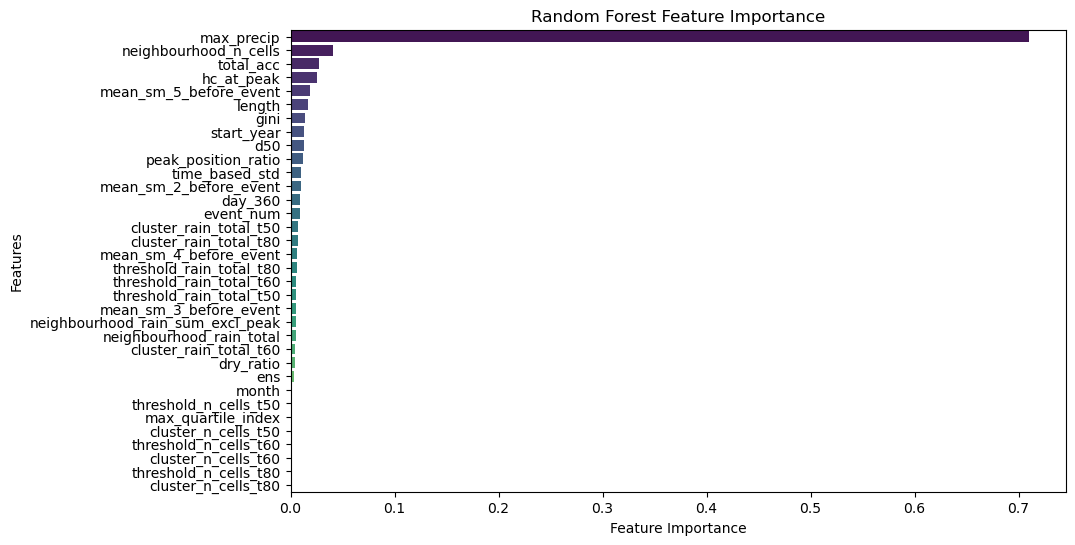

In [41]:
import seaborn as sns

# Assuming 'rf' is your trained RandomForestRegressor
feature_importances = pd.Series(rf.feature_importances_, index=explainer_variables)

# Sort descending
feature_importances = feature_importances.sort_values(ascending=False)

# Print
print(feature_importances)

# Optional: plot
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.show()

In [42]:
sub = rainfall_events_all_df[rainfall_events_all_df['HC_status'] == 'D']

# Split data into train/test
X_train, X_test, y_train, y_test = train_test_split(sub[explainer_variables], 
                                                    sub[predictor_variable], 
                                                    test_size=0.2, random_state=42)

# Fit Random Forest
rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Model performance
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))

R²: 0.4144799809478048
RMSE: 0.26669309709081235


total_acc                           0.260093
hc_at_peak                          0.117058
max_precip                          0.085003
neighbourhood_rain_total            0.052110
neighbourhood_n_cells               0.049635
time_based_std                      0.033323
gini                                0.028322
day_360                             0.025809
event_num                           0.025432
d50                                 0.022387
start_year                          0.021289
dry_ratio                           0.021095
neighbourhood_rain_sum_excl_peak    0.020783
cluster_rain_total_t80              0.019888
length                              0.018587
threshold_rain_total_t80            0.018558
peak_position_ratio                 0.017995
ens                                 0.016985
cluster_rain_total_t60              0.015704
threshold_rain_total_t50            0.015647
mean_sm_5_before_event              0.015604
threshold_rain_total_t60            0.015343
cluster_ra

/tmp/ipykernel_2244484/759885900.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")


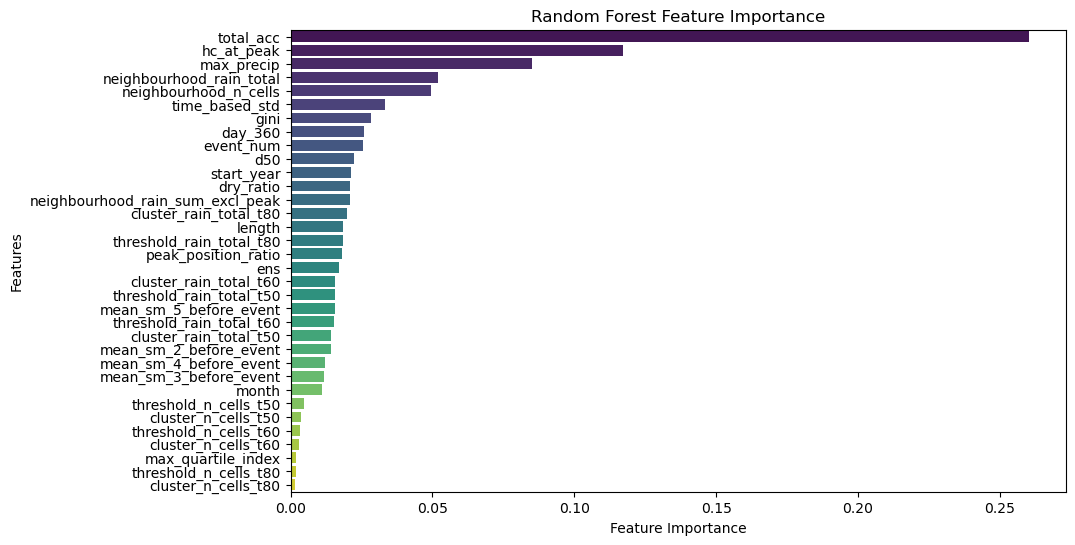

In [43]:
import seaborn as sns

# Assuming 'rf' is your trained RandomForestRegressor
feature_importances = pd.Series(rf.feature_importances_, index=explainer_variables)

# Sort descending
feature_importances = feature_importances.sort_values(ascending=False)

# Print
print(feature_importances)

# Optional: plot
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.show()

In [38]:
# Split data into train/test
X_train, X_test, y_train, y_test = train_test_split(rainfall_events_all_df[explainer_variables], 
                                                    rainfall_events_all_df[predictor_variable], 
                                                    test_size=0.2, random_state=42)

# Fit Random Forest
rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Model performance
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))

R²: 0.6371093069244917
RMSE: 0.10630223845273369


</div>

<div style="background-color: #f0faf0; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Categorising Hydraulic Conductivity (HC)

Soils are categorised into three classes based on hydraulic conductivity:
- **Low HC**: very impermeable soils (e.g., clay)
- **Medium HC**: moderately permeable soils (e.g., loam)
- **High HC**: very permeable soils (e.g., sand/gravel)


---

<details>
<summary> More info (click to expand)</summary>


## Expected Impact of HC on Sensitivity to Antecedent Conditions

### Low HC (Clay-dominated soils)
Clay soils have very small pore sizes and poor drainage, meaning water movement through the soil profile is slow. This produces several important characteristics:
- **Wet antecedent conditions persist** — once saturated, clay takes a long time to drain between events, giving the soil a long "memory" of previous rainfall
- **Infiltration capacity is low even when dry** — when wet, essentially all rainfall becomes runoff almost immediately
- **The contrast between wet and dry states is large and consequential** — a dry clay soil retains some residual capacity, a wet one has almost none, meaning antecedent state is a primary control on flood response
- In a warming climate, if summers become drier, clay soils might see *reduced* flood risk from individual events (greater buffering capacity), but autumn/winter events following wet periods could become more severe

### Medium HC (Loam-type soils)
- Moderate drainage means antecedent conditions matter, but less persistently than in clay soils
- These soils can partially recover between events, so the soil moisture signal may be more sensitive to the **specific lag time** used
- Likely the most variable class and hardest to generalise about

### High HC (Sandy/gravelly soils)
Sandy soils have large pore sizes and drain rapidly, leading to fundamentally different behaviour:
- **Antecedent conditions dissipate quickly** — even after a wet period, sandy soils can drain sufficiently between events that their state at the time of the next event is less extreme
- **Infiltration capacity remains high even when wet** — a large fraction of rainfall is absorbed regardless of antecedent state, reducing the contrast between wet and dry conditions
- **Flood response is more directly controlled by rainfall intensity** — flooding occurs when rainfall rate exceeds infiltration capacity (Hortonian overland flow), driven by storm characteristics rather than antecedent moisture

---

## Broader Implication

This framework suggests that the **dominant driver of flood generation differs spatially** across the UK:

| Soil Type | Dominant Flood Driver | Key Future Climate Sensitivity |
|---|---|---|
| Low HC (clay) | Antecedent soil moisture state | Changes in soil moisture seasonality |
| High HC (sand) | Rainfall intensity | Changes in extreme rainfall statistics |

These two pathways have different implications for how climate change translates into flood risk, and for which adaptation strategies are most relevant — making the spatial map of HC sensitivity a potentially important result. 

</details>


</div>

In [8]:
# rainfall_events_all_df_lowHC = rainfall_events_all_df[rainfall_events_all_df['hc_at_peak'] < 0.3]
# rainfall_events_all_df_medHC = rainfall_events_all_df[(rainfall_events_all_df['hc_at_peak'] >=0.3) & (rainfall_events_all_df['hc_at_peak'] < 0.7)]
# rainfall_events_all_df_highHC = rainfall_events_all_df[rainfall_events_all_df['hc_at_peak'] > 0.7]

# rainfall_events_all_df['HC_status'] = pd.cut( rainfall_events_all_df['hc_at_peak'],
#     bins=[-float('inf'), 0.3, 0.7, float('inf')],  labels=['low (clay)', 'medium', 'high (sand)'],right=False)

In [9]:
# hc_groups = {'low (clay)': rainfall_events_all_df_lowHC,
#              'medium (?)': rainfall_events_all_df_medHC,
#              'high (sandy)': rainfall_events_all_df_highHC}

In [59]:
rainfall_events_all_df_A = rainfall_events_all_df[rainfall_events_all_df['hc_at_peak'] >= 3]
rainfall_events_all_df_B = rainfall_events_all_df[(rainfall_events_all_df['hc_at_peak'] >=1.1) & (rainfall_events_all_df['hc_at_peak'] < 3)]
rainfall_events_all_df_C = rainfall_events_all_df[(rainfall_events_all_df['hc_at_peak'] >=0.15) & (rainfall_events_all_df['hc_at_peak'] < 1.1)]
rainfall_events_all_df_D = rainfall_events_all_df[rainfall_events_all_df['hc_at_peak'] < 0.15]

rainfall_events_all_df['HC_status'] = pd.cut(rainfall_events_all_df['hc_at_peak'],
    bins=[-float('inf'), 0.15, 1.1, 3, float('inf')],labels=['D', 'C', 'B', 'A'], right=False, include_lowest=True)

In [11]:
hc_groups = {'A': rainfall_events_all_df_A,
             'B': rainfall_events_all_df_B,
             'C': rainfall_events_all_df_C,
            'D': rainfall_events_all_df_D}

<div style="background-color: #f0faf0; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## How do antecedent conditions vary for rainfall events occurring on different soil types?
    
- **Low HC (clay):** Antecedent soil moisture conditions mostly between around 60-80 (soils generally wet when events occur)
- **Medium HC:** Similar but slightly broader range and shifted slightly lower
- **High HC (sand):** Dramatically wider and shifted right towards very high SM values (80-110) — but also with a long left tail down to near zero
    
</div>

In [12]:
# colors = ["red", "gold", "indigo", 'green']
color_map = {'A': 'red','B': 'gold','C': 'indigo','D': 'green'}

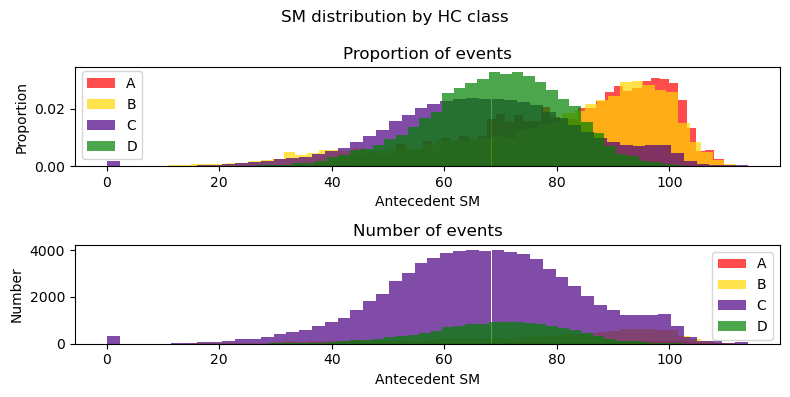

In [13]:
fig, axs = plt.subplots(nrows= 2, figsize=(8, 4))
for hc_label, hc_df in hc_groups.items():
    hc_df['mean_sm_2_before_event'].plot.hist(ax=axs[0], alpha=0.7, density=True, bins=50, label=hc_label, 
                                              color = color_map[hc_label])
axs[0].set_xlabel('Antecedent SM')
axs[0].set_ylabel('Proportion')
axs[0].legend()
axs[0].set_title('Proportion of events')

for hc_label, hc_df in hc_groups.items():
    hc_df['mean_sm_2_before_event'].plot.hist(ax=axs[1], alpha=0.7, density=False, bins=50, label=hc_label, 
                                              color = color_map[hc_label])
axs[1].set_xlabel('Antecedent SM')
axs[1].set_ylabel('Number')
axs[1].legend()
axs[1].set_title('Number of events')
fig.suptitle('SM distribution by HC class')
fig.tight_layout()

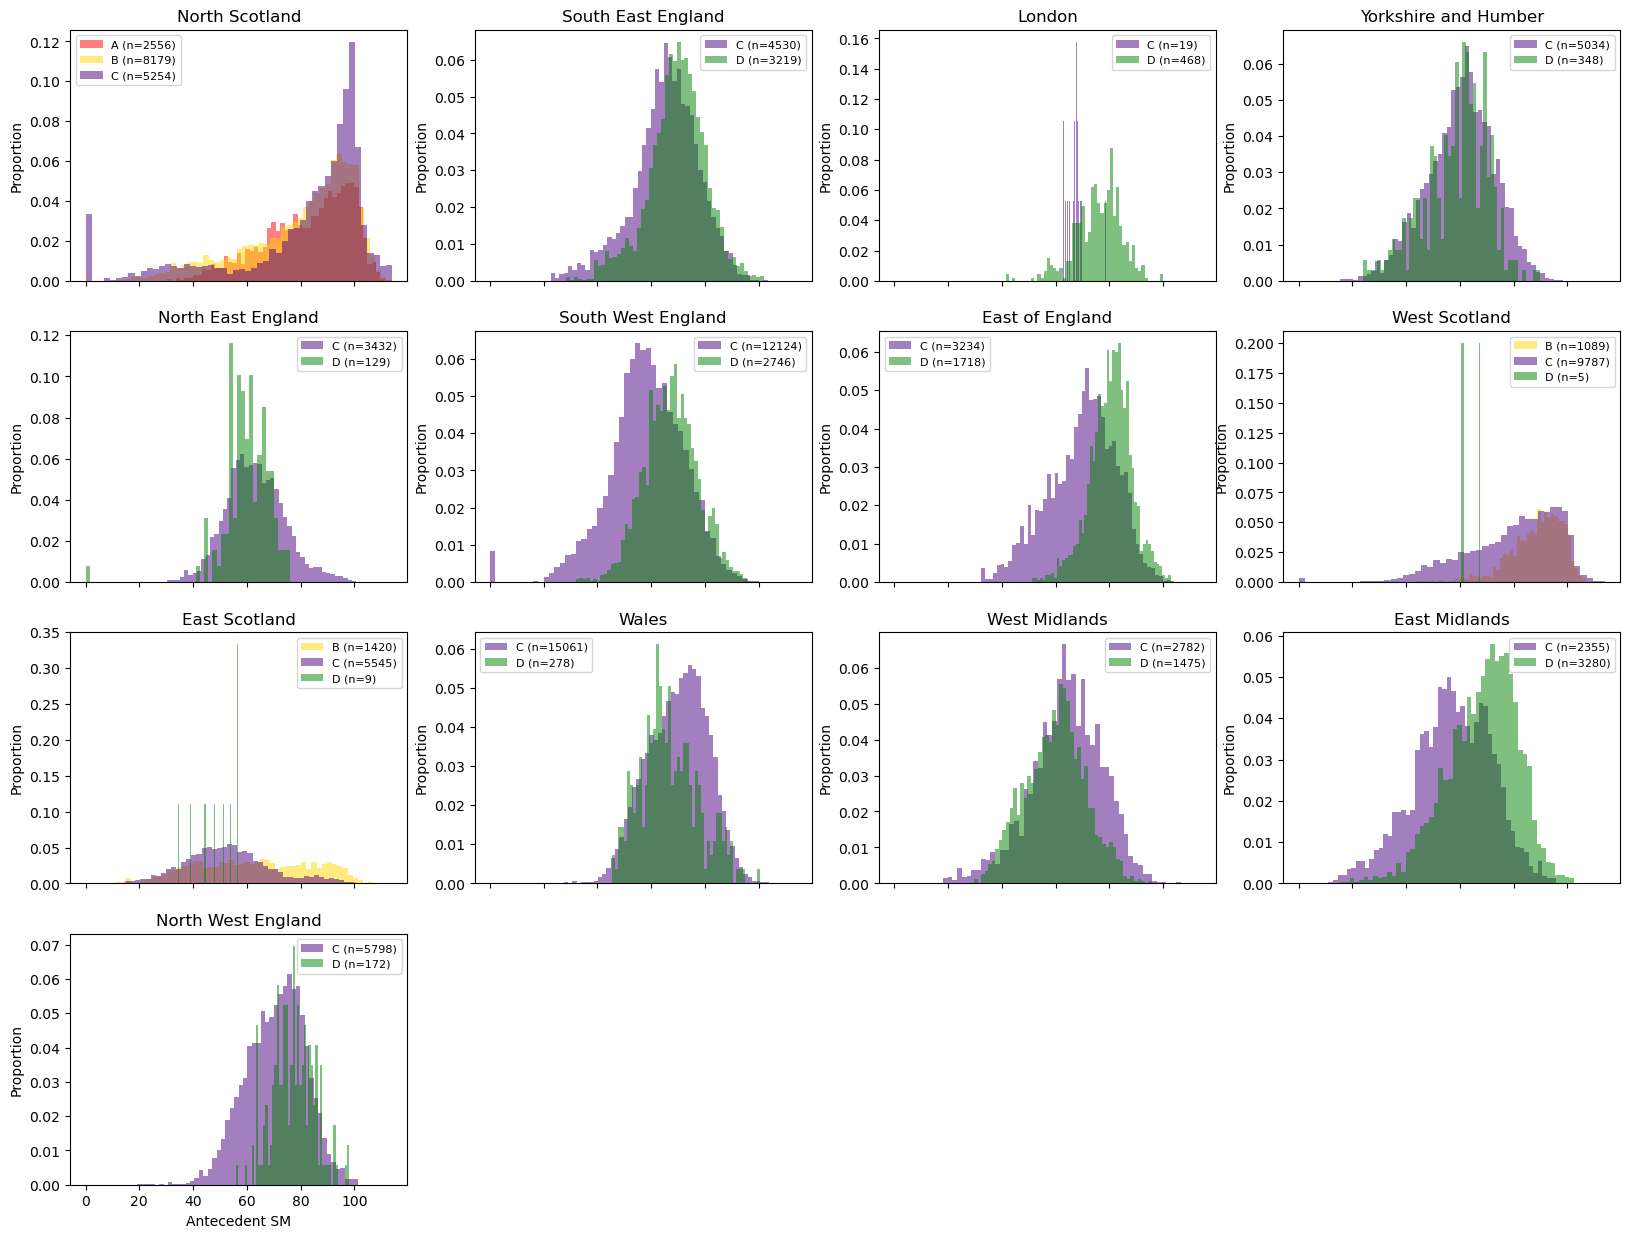

In [14]:
regions_list = rainfall_events_all_df['geo_region'].unique().tolist()

fig, axes = plt.subplots(4, 4, figsize=(20, 15), sharex=True, sharey=False)
axes = axes.flatten()

for i, region in enumerate(regions_list):
    
    ax = axes[i]
    
    # Filter to region
    df_region = rainfall_events_all_df[rainfall_events_all_df['geo_region'] == region]
    
    for hc_label in ['A', 'B', 'C', 'D']:
        subset = df_region[df_region['HC_status'] == hc_label]

        if subset.empty:
            continue

        n = len(subset)  # 👈 sample size

        subset['mean_sm_2_before_event'].plot.hist(
            ax=ax,
            alpha=0.5,
            bins=50,
            weights=np.ones(n) / n,
            label=f"{hc_label} (n={n})",  # 👈 add to legend
            color=color_map[hc_label]
        )
        
    ax.set_title(region)
    ax.set_xlabel('Antecedent SM')
    ax.set_ylabel('Proportion')
    ax.legend(fontsize=8)  # 👈 make sure legend shows

# remove unused axes
n_regions = len(regions_list)
for j in range(n_regions, len(axes)):
    fig.delaxes(axes[j])

/tmp/ipykernel_1864900/1798447866.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = (rainfall_events_all_df.groupby(['geo_region', 'HC_status'])['mean_sm_2_before_event']


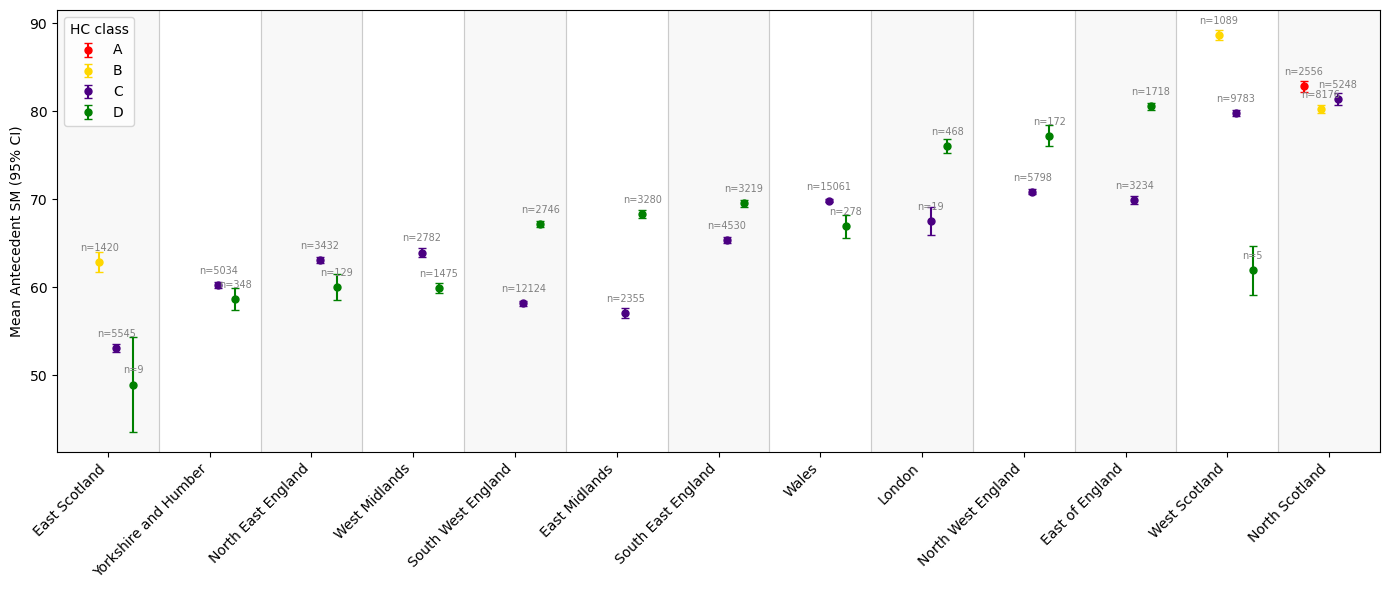

In [15]:
summary = (rainfall_events_all_df.groupby(['geo_region', 'HC_status'])['mean_sm_2_before_event']
    .agg(['mean', 'median', 'std', 'count'])
    .reset_index())

# 95% CI using SEM (swap for bootstrap CI if distributions are skewed/non-normal)
summary['sem'] = summary['std'] / np.sqrt(summary['count'])
summary['ci95'] = 1.96 * summary['sem']

# Order regions however you like (e.g. by overall mean, or alphabetically, or geographically)
region_order = summary.groupby('geo_region')['mean'].mean().sort_values().index.tolist()
class_order = ['A', 'B', 'C', 'D']
colors = color_map
region_lookup = pd.DataFrame({'geo_region': region_order})

fig, ax = plt.subplots(figsize=(14, 6))  # wider figure = more breathing room

n_classes = len(class_order)
offsets = np.linspace(-0.25, 0.25, n_classes)

for i, hc_class in enumerate(class_order):
    sub = summary[summary['HC_status'] == hc_class]
    sub = region_lookup.merge(sub, on='geo_region', how='left')
    

    x = np.arange(len(region_order)) + offsets[i]
    y = sub['mean'].values
#     yerr = sub['std'].values 
    yerr = sub['ci95'].values

    ax.errorbar(x, y, yerr=yerr, fmt='o', color=colors[hc_class],
                label=hc_class, capsize=3, markersize=5)

    for xi, (cnt, m) in enumerate(zip(sub['count'], y)):
        if pd.notna(cnt):
            ax.annotate(f'n={int(cnt)}',
                        (x[xi], m),
                        fontsize=7,
                        color='gray',
                        xytext=(0, 8),
                        textcoords='offset points',
                        ha='center')

# Vertical lines between each region group (at the midpoint between regions)
for j in range(len(region_order) - 1):
    ax.axvline(j + 0.5, color='lightgray', linestyle='-', linewidth=0.8, zorder=0)

# Optional: alternating shaded background bands instead of/as well as lines
for j in range(len(region_order)):
    if j % 2 == 0:
        ax.axvspan(j - 0.5, j + 0.5, color='gray', alpha=0.05, zorder=0)

ax.set_xticks(np.arange(len(region_order)))
ax.set_xticklabels(region_order, rotation=45, ha='right')
ax.set_xlim(-0.5, len(region_order) - 0.5)
ax.set_ylabel('Mean Antecedent SM (95% CI)')
ax.legend(title='HC class')
plt.tight_layout()
plt.show()

<div style="background-color: #f0faf0; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## XXX

</div>

In [16]:
import pickle
pickle_path = '../../Data/SoilInfo/all_years_data.pickle'
if os.path.exists(pickle_path):
    print("Reading from file")
    with open(pickle_path, 'rb') as handle:
        all_years_data = pickle.load(handle)

else:        
    # Create empty dictionary to store results 
    all_years_data = {label: [] for label in bin_labels}

    # Loop over ensembles and years
    for ens in ENSEMBLE_MEMBERS:
        # Load soil moisture data
        sm_dir  = f'/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_{ens}/'
        for year in tqdm(range(1980, 2080)):
            # Get the soil moisture data
            try:
                sm_file = glob.glob(f"{sm_dir}/r001i1p*****_{year-1}1201-{year}1130_mrso.nc")[0]
            except IndexError:
                continue

            sm_yr = iris.load(sm_file)[0]
            # Convert masked → NaN
            sm_arr = sm_yr.data.filled(np.nan) if np.ma.is_masked(sm_yr.data) else sm_yr.data

            # Extract data by HK class
            for i, label in enumerate(bin_labels):
                # Build a spatial mask for each HK class
                mask = classified == (i )
                # Compute daily mean soil moisture for that class
                all_years_data[label].append({"ensemble": ens,"year": year, "data": np.nanmean(sm_arr[:, mask], axis=1) })
                
                
    with open(pickle_path, 'wb') as handle:
        pickle.dump(all_years_data, handle, protocol=pickle.HIGHEST_PROTOCOL)

Reading from file


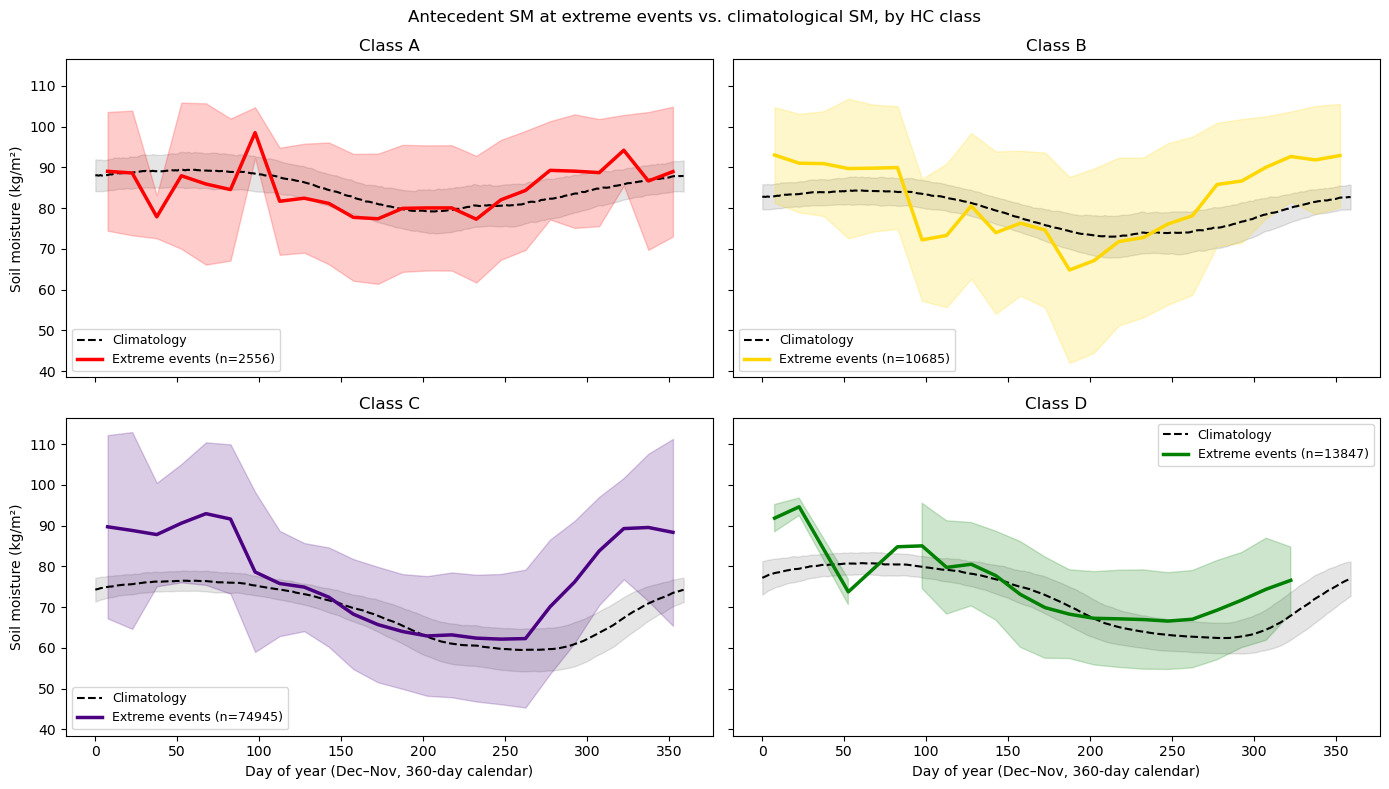

In [17]:
days = np.arange(360)
color_map = {'A': 'red', 'B': 'gold', 'C': 'indigo', 'D': 'green'}

hc_classes = {'A': rainfall_events_all_df_A, 'B': rainfall_events_all_df_B,
    'C': rainfall_events_all_df_C, 'D': rainfall_events_all_df_D}

bin_width = 15
bin_edges = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bin_edges[:-1] + bin_width / 2

fig, axs = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axs = axs.flatten()

for ax, label in zip(axs, color_map.keys()):
    # --- climatology baseline ---
    stack = np.stack([entry["data"] for entry in all_years_data[label]], axis=0)
    clim_mean = np.nanmean(stack, axis=0)
    clim_std = np.nanstd(stack, axis=0)

    ax.plot(days, clim_mean, color='black', linestyle='--', linewidth=1.5, label="Climatology")
    ax.fill_between(days, clim_mean - clim_std, clim_mean + clim_std, alpha=0.1, color='black')

    # --- extreme events only, binned ---
    df = hc_classes[label].dropna(subset=['day_360', 'mean_sm_2_before_event']).copy()
    df['day_bin'] = pd.cut(df['day_360'], bins=bin_edges, labels=bin_centers, include_lowest=True)

    grouped = df.groupby('day_bin', observed=True)['mean_sm_2_before_event']
    binned_mean = grouped.mean()
    binned_std = grouped.std()

    x = binned_mean.index.astype(float)
    ax.plot(x, binned_mean.values, color=color_map[label], linewidth=2.5, label=f"Extreme events (n={len(df)})")
    ax.fill_between(x, binned_mean.values - binned_std.values, binned_mean.values + binned_std.values,
                     alpha=0.2, color=color_map[label])

    ax.set_title(f"Class {label}")
    ax.legend(fontsize=9)

for ax in axs[2:]:
    ax.set_xlabel("Day of year (Dec–Nov, 360-day calendar)")
for ax in [axs[0], axs[2]]:
    ax.set_ylabel("Soil moisture (kg/m²)")

fig.suptitle("Antecedent SM at extreme events vs. climatological SM, by HC class")
plt.tight_layout()
plt.show()

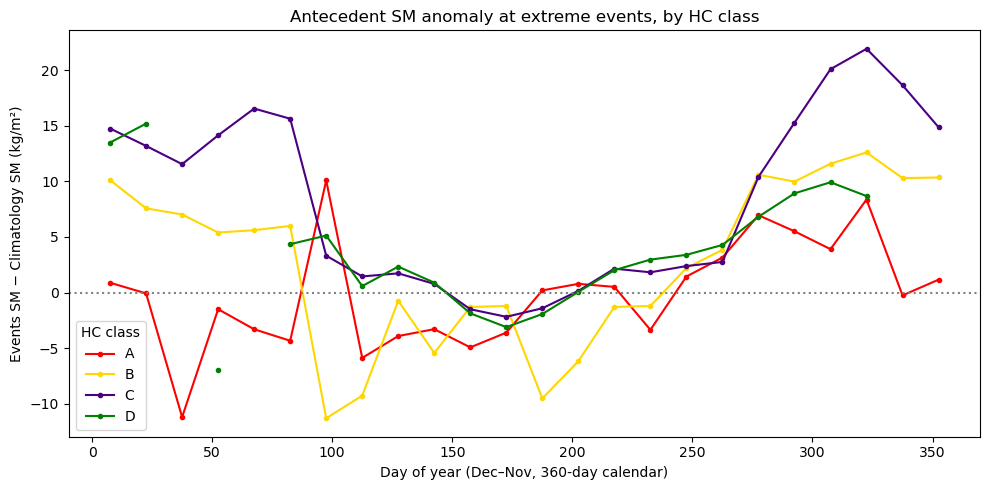

In [18]:
hc_classes = {'A': rainfall_events_all_df_A, 'B': rainfall_events_all_df_B,
    'C': rainfall_events_all_df_C, 'D': rainfall_events_all_df_D}
color_map = {'A': 'red', 'B': 'gold', 'C': 'indigo', 'D': 'green'}

bin_width = 15
bin_edges = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bin_edges[:-1] + bin_width / 2

binned_events_mean = {}
binned_clim_mean = {}

for label, df in hc_classes.items():
    # --- events, binned ---
    df = df.dropna(subset=['day_360', 'mean_sm_2_before_event']).copy()
    df['day_bin'] = pd.cut(df['day_360'], bins=bin_edges, labels=bin_centers, include_lowest=True)
    grouped = df.groupby('day_bin', observed=True)['mean_sm_2_before_event'].mean()
    # reindex onto full bin_centers grid so all classes align, even if a bin has zero events
    binned_events_mean[label] = grouped.reindex(bin_centers)

    # --- climatology, interpolated onto same day-bin grid ---
    stack = np.stack([entry["data"] for entry in all_years_data[label]], axis=0)
    clim_mean_daily = np.nanmean(stack, axis=0)  # (360,) - daily resolution
    # interpolate the daily climatology onto the coarser bin_centers
    clim_at_bins = np.interp(bin_centers, days, clim_mean_daily)
    binned_clim_mean[label] = pd.Series(clim_at_bins, index=bin_centers)

# --- anomaly plot ---
fig, ax = plt.subplots(figsize=(10, 5))
for label in hc_classes.keys():
    anomaly = binned_events_mean[label] - binned_clim_mean[label]
    ax.plot(bin_centers, anomaly, label=label, color=color_map[label], marker='o', markersize=3)

ax.axhline(0, color='gray', linestyle=':')
ax.set_xlabel("Day of year (Dec–Nov, 360-day calendar)")
ax.set_ylabel("Events SM − Climatology SM (kg/m²)")
ax.set_title("Antecedent SM anomaly at extreme events, by HC class")
ax.legend(title="HC class")
plt.tight_layout()
plt.show()

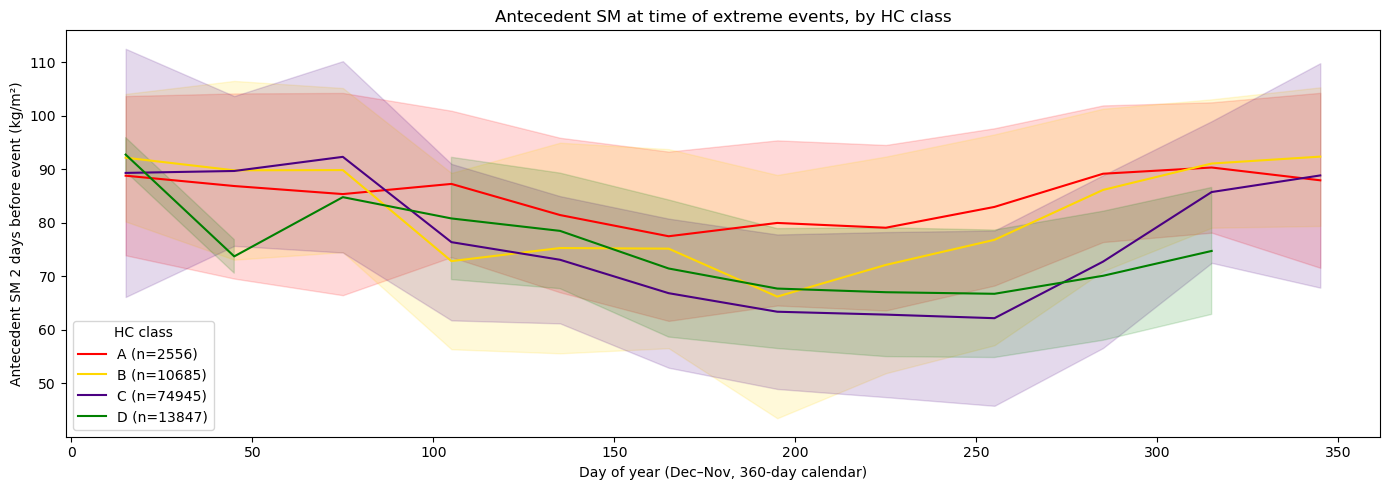

In [19]:
hc_classes = {'A': rainfall_events_all_df_A, 'B': rainfall_events_all_df_B,
    'C': rainfall_events_all_df_C, 'D': rainfall_events_all_df_D}
color_map = {'A': 'red', 'B': 'gold', 'C': 'indigo', 'D': 'green'}

bin_width = 30  # days - widen if still noisy, narrow if you have enough events
bin_edges = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bin_edges[:-1] + bin_width / 2

fig, ax = plt.subplots(figsize=(14, 5))

for label, df in hc_classes.items():
    df = df.dropna(subset=['day_360', 'mean_sm_2_before_event'])
    df = df.copy()
    df['day_bin'] = pd.cut(df['day_360'], bins=bin_edges, labels=bin_centers, include_lowest=True)

    grouped = df.groupby('day_bin', observed=True)['mean_sm_2_before_event']
    binned_mean = grouped.mean()
    binned_std = grouped.std()
    binned_n = grouped.count()

    x = binned_mean.index.astype(float)
    ax.plot(x, binned_mean.values, label=f"{label} (n={df.shape[0]})", color=color_map[label])
    ax.fill_between(x, binned_mean.values - binned_std.values, binned_mean.values + binned_std.values,
                     alpha=0.15, color=color_map[label])

ax.set_xlabel("Day of year (Dec–Nov, 360-day calendar)")
ax.set_ylabel("Antecedent SM 2 days before event (kg/m²)")
ax.set_title("Antecedent SM at time of extreme events, by HC class")
ax.legend(title="HC class")
plt.tight_layout()
plt.show()

<div style="background-color: #f0faf0; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## How do antecedent conditions change in future for different soil types?
    
- Low HC (clay): Antecedent soil moisture conditions getting drier
- Medium HC: Antecedent soil moisture conditions getting drier
- High HC (sand): Antecedent soil moisture conditions getting wetter
    
Implications of this:
- Clay soils are almost always wet when AMAX events occur: less variability to differentiate over
    - Is this because Clay soils are basically always wet, or only when we sample the AMAX events?
</div>

In [20]:
# cmap = plt.get_cmap('Reds')
# values = np.linspace(0.2, 0.9, 3)
# colors = [cmap(v) for v in values]

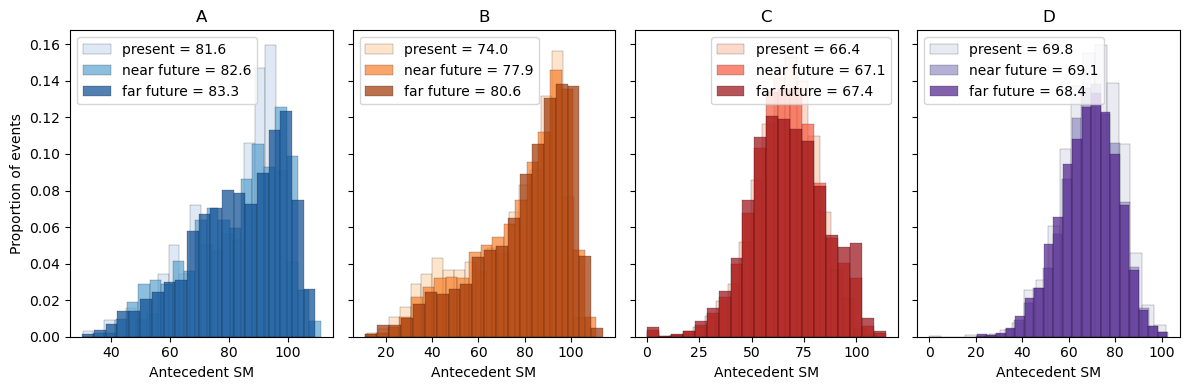

In [21]:
fig, axs = plt.subplots(ncols=4, figsize=(12, 4), sharey=True)
titles = ['A', 'B', 'C', 'D']
color_ramps = [ 'Blues', 'Oranges', 'Reds', 'Purples']
for ax_num, rainfall_events in enumerate([
    rainfall_events_all_df_A,rainfall_events_all_df_B,
    rainfall_events_all_df_C,rainfall_events_all_df_D]):
    
    cmap = plt.get_cmap(color_ramps[ax_num])
    values = np.linspace(0.2, 0.9, 3)
    colors = [cmap(v) for v in values]
    
    year_groups = { 'present': rainfall_events[rainfall_events['start_year'] < 2020],
        'near future': rainfall_events[(rainfall_events['start_year'] >= 2020) & (rainfall_events['start_year'] <= 2050)],
        'far future': rainfall_events[rainfall_events['start_year'] > 2050], }

    # Plot + annotate
#     for i, (hc_label, hc_df) in enumerate(year_groups.items()):
#         hc_df['mean_sm_2_before_event'].plot.hist(
#             ax=axs[ax_num],
#             alpha=0.7,
#             bins=20,
#             label=f"{hc_label} = {mean_val:.1f}",
#             density=True,
#             color=colors[i],
#             edgecolor = 'black', linewidth=0.2)
        
#         mean_val = hc_df['mean_sm_2_before_event'].mean()
        

    for i, (hc_label, hc_df) in enumerate(year_groups.items()):
        mean_val = hc_df['mean_sm_2_before_event'].mean()

        hc_df['mean_sm_2_before_event'].plot.hist(
            ax=axs[ax_num],
            alpha=0.7,
            bins=20,
            label=f"{hc_label} = {mean_val:.1f}",
            weights=np.ones(len(hc_df)) / len(hc_df),
            color=colors[i],
            edgecolor='black', linewidth=0.2)


    axs[ax_num].set_xlabel('Antecedent SM')
    axs[ax_num].set_ylabel('Proportion of events')
    axs[ax_num].legend()
    
    axs[ax_num].set_title(titles[ax_num])

plt.tight_layout()

<div style="background-color: #f0faf0; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Do events tend to happen at different times of year on different soil types?
    
- Low HC (clay): Mostly tightly concentrated around summer
- Medium HC: Mostly tightly concentrated around summer
- High HC (sand): Fatter tail into winter (days 280-360) and also more events in early spring (days 0-100)
    
Sandier soils experience more winter events proportionally.      
</div>

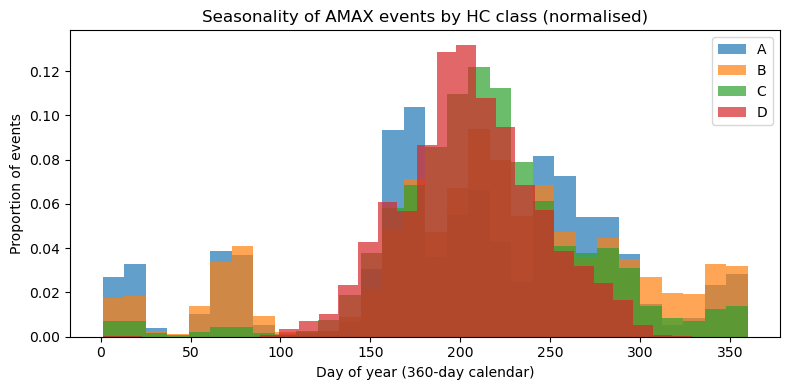

In [22]:
# fig, ax = plt.subplots(figsize=(8, 4))
# for hc_label, hc_df in hc_groups.items():
#     hc_df['day_360'].plot.hist( ax=ax, alpha=0.7, bins=30, label=hc_label, density=True)
# ax.set_xlabel('Day of year (360-day calendar)')
# ax.set_ylabel('Proportion of events')
# ax.legend()
# ax.set_title('Seasonality of AMAX events by HC class (normalised)')
# plt.tight_layout()

fig, ax = plt.subplots(figsize=(8, 4))
for hc_label, hc_df in hc_groups.items():
    hc_df['day_360'].plot.hist(
        ax=ax, alpha=0.7, bins=30, label=hc_label,
        weights=np.ones(len(hc_df)) / len(hc_df))
ax.set_xlabel('Day of year (360-day calendar)')
ax.set_ylabel('Proportion of events')
ax.legend()
ax.set_title('Seasonality of AMAX events by HC class (normalised)')
plt.tight_layout()

</div>

<div style="background-color: #f0faf0; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Exploratory plots: Does the rainfall-flood relationship change across HC classes?
- Relationship beteen rainfall and flooding is strongest in the high HC cells (it is slightly higher in the low HC cells than the medium ones)

</div>

In [23]:
def get_fit_stats(df, x_col, y_col):
    """Returns slope, r-squared, and p-value for a linear fit."""
    clean = df[[x_col, y_col]].dropna()
    slope, intercept, r, p, se = stats.linregress(clean[x_col], clean[y_col])
    return {'slope': slope, 'r2': r**2, 'pvalue': p, 'n': len(clean)}

metrics = [('max_precip', '10cm_area'),
#            ('max_precip', '30cm_area'),
#            ('max_precip', '10cm_volume'),
#            ('max_precip', '30cm_volume')
          ]

hc_groups = {'A': rainfall_events_all_df_A,
             'B': rainfall_events_all_df_B,
             'C': rainfall_events_all_df_C,
              'D': rainfall_events_all_df_D,
            }

rows = []
for hc_label, hc_df in hc_groups.items():
    for (x, y) in metrics:
        stats_dict = get_fit_stats(hc_df, x, y)
        rows.append({'HC_class': hc_label, 'x': x, 'y': y, **stats_dict})

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

HC_class          x         y    slope       r2  pvalue     n
       A max_precip 10cm_area 0.006284 0.591215     0.0  2556
       B max_precip 10cm_area 0.012011 0.581520     0.0 10688
       C max_precip 10cm_area 0.015375 0.144681     0.0 74955
       D max_precip 10cm_area 0.028800 0.191989     0.0 13847


In [24]:
rainfall_events_all_df_D_wet = rainfall_events_all_df_C[rainfall_events_all_df_C['mean_sm_2_before_event']>90]

In [44]:
def plot_with_best_fit_line(results_df, ax, col1, col2, label1, label2, title):
    x = results_df[col1]
    y = results_df[col2]
    c = results_df['gini']
    
    sc = ax.scatter(x, y, c=c, cmap='Blues')

    # 🔹 Fit line
    m, b = np.polyfit(x, y, 1)

    # Predicted values
    y_pred = m * x + b

    # R²
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - (ss_res / ss_tot)

    # 🔹 Create line values
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = m * x_line + b

    # 🔹 Plot line
    ax.plot(x_line, y_line, color='black')

    ax.text( 0.05, 0.95,  f'$R^2 = {r2:.2f}$', transform=ax.transAxes, verticalalignment='top')

    ax.set_xlabel(label1)
    ax.set_ylabel(label2)
    
    ax.set_title(title)
    return sc

/home/kv25483/anaconda3/envs/geo_env2/lib/python3.10/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


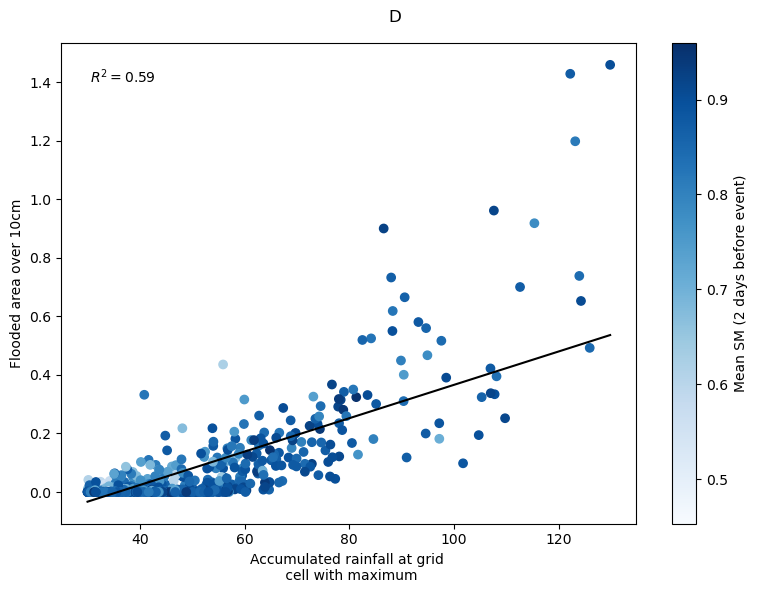

In [47]:
rainfall_events = rainfall_events_all_df_A
rainfall_events['length'] = rainfall_events['stop_idx'] - rainfall_events['start_idx']
rainfall_events =rainfall_events[rainfall_events['length'] < 30] 

fig, ax = plt.subplots(figsize=(8,6))

plotting_dict1 = {('max_precip', '10cm_area'): ('Accumulated rainfall at grid \n cell with maximum','Flooded area over 10cm')}

for (variable1, variable2), (var_name1, var_name2) in plotting_dict1.items():
    sc = plot_with_best_fit_line(rainfall_events, ax, variable1, variable2, var_name1, var_name2, '')
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Mean SM (2 days before event)')
        
fig.suptitle('D')
fig.tight_layout()


/home/kv25483/anaconda3/envs/geo_env2/lib/python3.10/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


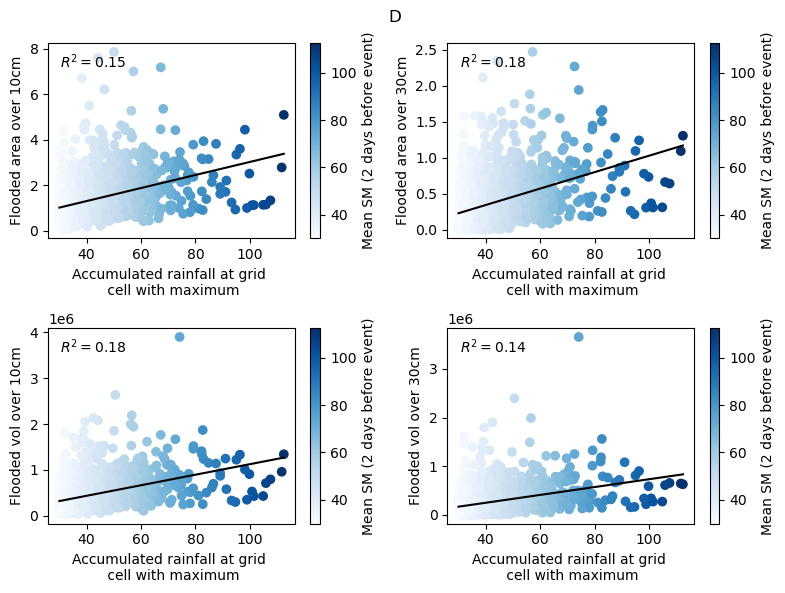

In [43]:
rainfall_events = rainfall_events_all_df_D
rainfall_events['length'] = rainfall_events['stop_idx'] - rainfall_events['start_idx']
rainfall_events =rainfall_events[rainfall_events['length'] > 30] 

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8,6))
axs=axs.flatten()
plotting_dict1 = {('max_precip', '10cm_area'): ('Accumulated rainfall at grid \n cell with maximum','Flooded area over 10cm')}
plotting_dict2 = {('max_precip', '30cm_area'): ('Accumulated rainfall at grid \n cell with maximum','Flooded area over 30cm')}
plotting_dict3 = {('max_precip', '10cm_volume'): ('Accumulated rainfall at grid \n cell with maximum','Flooded vol over 10cm')}
plotting_dict4 = {('max_precip', '30cm_volume'): ('Accumulated rainfall at grid \n cell with maximum','Flooded vol over 30cm')}

for ax_num, plotting_dict in enumerate([plotting_dict1, plotting_dict2, plotting_dict3, plotting_dict4]):
    for (variable1, variable2), (var_name1, var_name2) in plotting_dict.items():
        sc = plot_with_best_fit_line(rainfall_events, axs[ax_num], variable1, variable2, var_name1, var_name2, '')
        cbar = plt.colorbar(sc, ax=axs[ax_num])
        cbar.set_label('Mean SM (2 days before event)')
        
fig.suptitle('D')
fig.tight_layout()


In [29]:
def add_sm_bin(df, col='mean_sm_2_before_event', bins=3, labels=('dry', 'medium', 'wet'), 
               fixed_edges=None):
    if fixed_edges is not None:
        df = df.copy()
        df['sm_bin'] = pd.cut(df[col], bins=fixed_edges, labels=labels)
    else:
        df = df.copy()
        df['sm_bin'] = pd.qcut(df[col], q=bins, labels=labels)
    return df

fixed_edges = pd.qcut(rainfall_events_all_df['mean_sm_2_before_event'], q=3, retbins=True)[1]

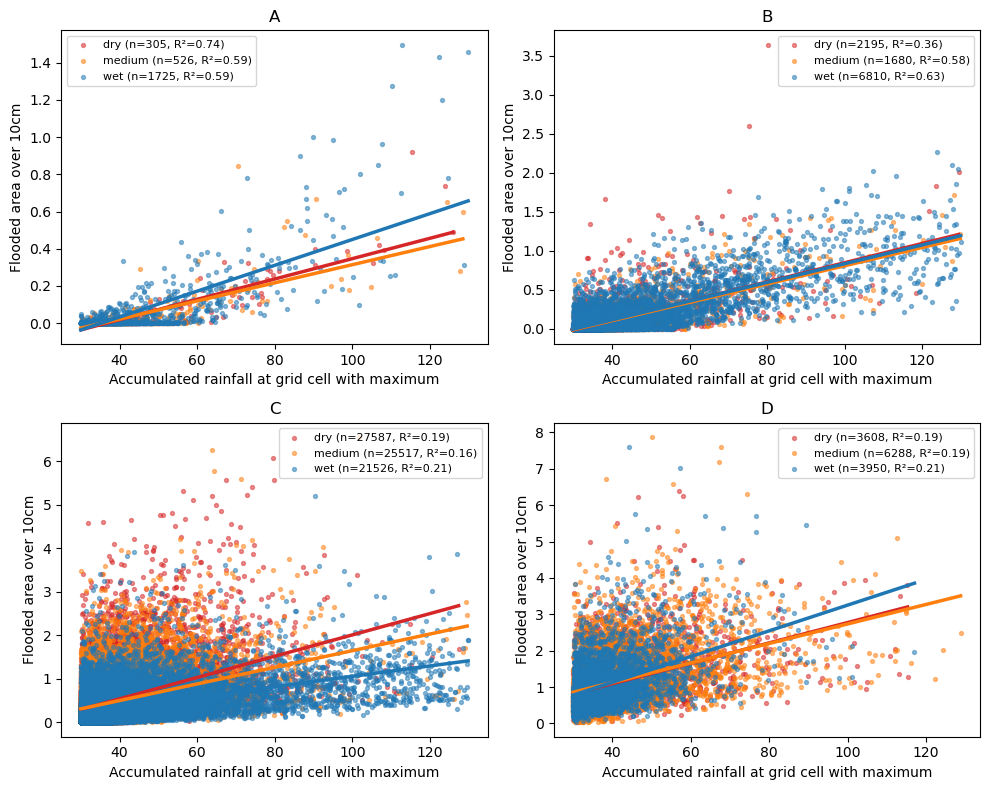

In [30]:
from sklearn.linear_model import LinearRegression

metrics = [('10cm_volume', 'Flooded area over 10cm')]

sm_colors = {'dry': 'tab:red', 'medium': 'tab:orange', 'wet': 'tab:blue'}

metric = '10cm_area'
y_label = 'Flooded area over 10cm'

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

for ax, hc_class in zip(axs.flat, ['A', 'B', 'C', 'D']):
    
    df = hc_groups[hc_class]
    df = add_sm_bin(df, fixed_edges=fixed_edges)

    for sm_bin, color in sm_colors.items():
        sub = df[df['sm_bin'] == sm_bin].dropna(subset=['max_precip', metric])
        if len(sub) < 5:
            continue

        X = sub[['max_precip']].values
        y = sub[metric].values

        reg = LinearRegression().fit(X, y)
        r2 = reg.score(X, y)  # <-- R² here

        # scatter
        ax.scatter(sub['max_precip'], sub[metric], s=8, alpha=0.5,
                   color=color,
                   label=f"{sm_bin} (n={len(sub)}, R²={r2:.2f})")

        # regression line
        xs = np.linspace(sub['max_precip'].min(), sub['max_precip'].max(), 50)
        ax.plot(xs, reg.predict(xs.reshape(-1, 1)), color=color, linewidth=2.5)

    ax.set_xlabel('Accumulated rainfall at grid cell with maximum')
    ax.set_ylabel(y_label)
    ax.set_title(f"{hc_class}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

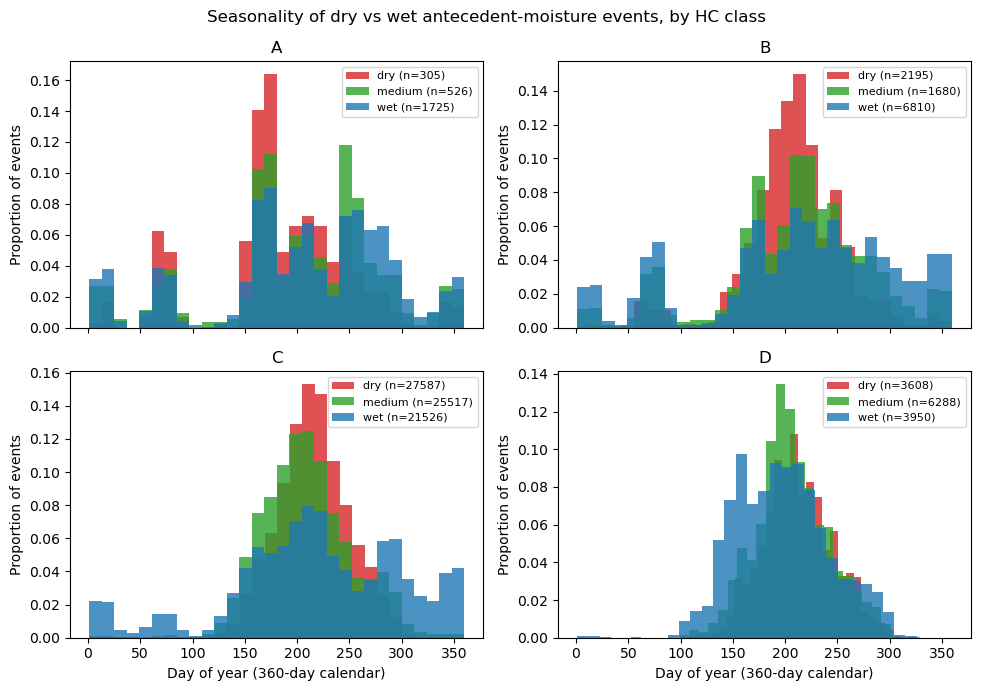

In [31]:
hc_classes = {'A': rainfall_events_all_df_A, 'B': rainfall_events_all_df_B,
              'C': rainfall_events_all_df_C, 'D': rainfall_events_all_df_D}

fig, axs = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
axs = axs.flatten()

for ax, (hc_label, df) in zip(axs, hc_classes.items()):
    df = add_sm_bin(df, fixed_edges=fixed_edges)  # reuse your existing fixed-edge binning
    for sm_bin, color in {'dry': 'tab:red', 'medium':'tab:green', 'wet': 'tab:blue'}.items():
        sub = df[df['sm_bin'] == sm_bin].dropna(subset=['day_360'])
        sub['day_360'].plot.hist(
            ax=ax, bins=30, alpha=0.8, color=color,
            weights=np.ones(len(sub)) / len(sub),
            label=f"{sm_bin} (n={len(sub)})")
    ax.set_title(hc_label)
    ax.set_xlabel('Day of year (360-day calendar)')
    ax.set_ylabel('Proportion of events')
    ax.legend(fontsize=8)

fig.suptitle('Seasonality of dry vs wet antecedent-moisture events, by HC class')
plt.tight_layout()
plt.show()

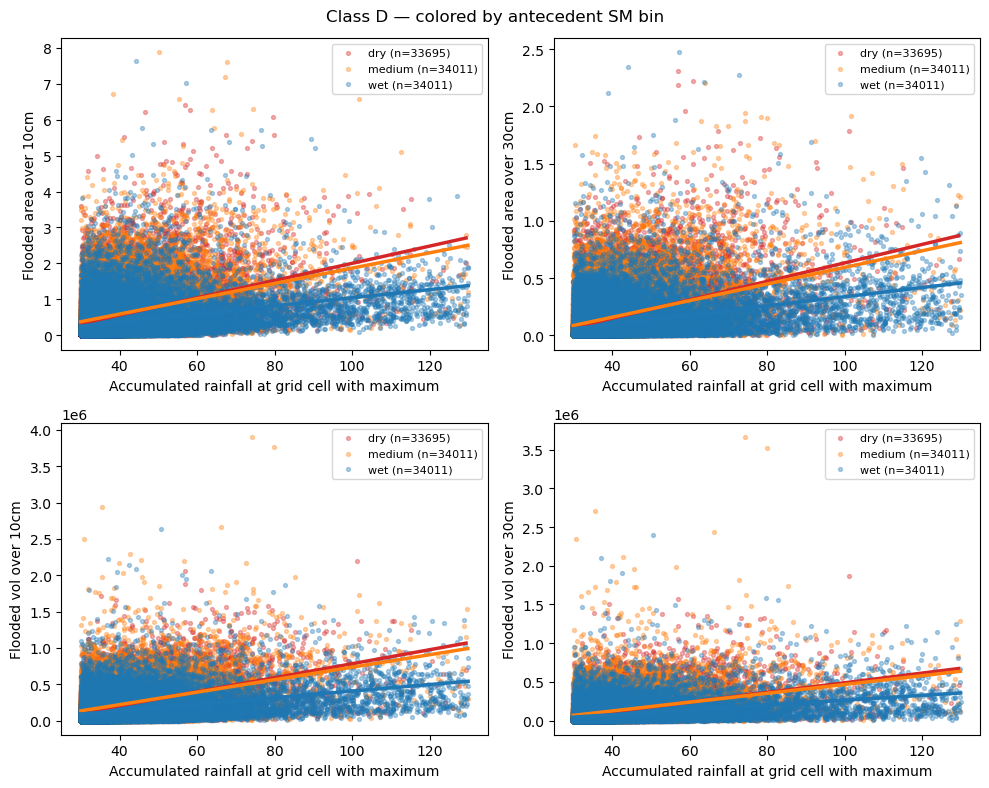

In [32]:
from sklearn.linear_model import LinearRegression

df = rainfall_events_all_df.copy()
df = add_sm_bin(df, fixed_edges=fixed_edges)  # from earlier - keeps SM bins consistent across classes

metrics = [ ('10cm_area', 'Flooded area over 10cm'),('30cm_area', 'Flooded area over 30cm'),
    ('10cm_volume', 'Flooded vol over 10cm'), ('30cm_volume', 'Flooded vol over 30cm'),]

sm_colors = {'dry': 'tab:red', 'medium': 'tab:orange', 'wet': 'tab:blue'}

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

for ax, (metric, ylabel) in zip(axs.flat, metrics):
    for sm_bin, color in sm_colors.items():
        sub = df[df['sm_bin'] == sm_bin].dropna(subset=['max_precip', metric])
        if len(sub) < 5:
            continue

        ax.scatter(sub['max_precip'], sub[metric], s=8, alpha=0.35,
                   color=color, label=f"{sm_bin} (n={len(sub)})")

        X = sub[['max_precip']].values
        y = sub[metric].values
        reg = LinearRegression().fit(X, y)
        xs = np.linspace(sub['max_precip'].min(), sub['max_precip'].max(), 50)
        ax.plot(xs, reg.predict(xs.reshape(-1, 1)), color=color, linewidth=2.5)

    ax.set_xlabel('Accumulated rainfall at grid cell with maximum')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

fig.suptitle('Class D — colored by antecedent SM bin')
plt.tight_layout()
plt.show()

In [33]:
# from scipy.stats import pearsonr, spearmanr

# hc_classes = {'A': rainfall_events_all_df_A, 'B': rainfall_events_all_df_B,
#               'C': rainfall_events_all_df_C, 'D': rainfall_events_all_df_D}

# metrics = ['10cm_area', '30cm_area', '10cm_volume', '30cm_volume']
# results = []

# for hc_label, df in hc_classes.items():
#     df = add_sm_bin(df, fixed_edges=fixed_edges)
#     for sm_bin in ['dry', 'medium', 'wet']:
#         sub = df[df['sm_bin'] == sm_bin].dropna(subset=['max_precip'])
#         for metric in metrics:
#             valid = sub.dropna(subset=[metric])
#             if len(valid) < 5:  # guard against tiny samples
#                 r, rho, n = np.nan, np.nan, len(valid)
#             else:
#                 r, _ = pearsonr(valid['max_precip'], valid[metric])
#                 rho, _ = spearmanr(valid['max_precip'], valid[metric])
#                 n = len(valid)
#             results.append({'hc_class': hc_label, 'sm_bin': sm_bin, 'metric': metric,
#                              'pearson_r': r, 'spearman_rho': rho, 'n': n})

# corr_df = pd.DataFrame(results)

# import seaborn as sns

# for metric in metrics:
#     pivot = corr_df[corr_df['metric'] == metric].pivot(index='hc_class', columns='sm_bin', values='pearson_r')
#     pivot = pivot[['dry', 'medium', 'wet']]  # enforce column order
#     plt.figure(figsize=(4, 3))
#     sns.heatmap(pivot, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, center=0)
#     plt.title(f'Pearson r: max_precip vs {metric}')
#     plt.show()

## ADD ALL FOR ALL WETNESS STATES

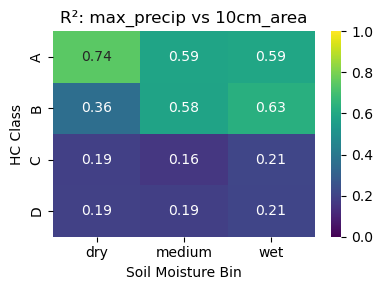

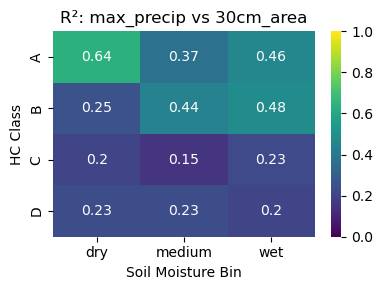

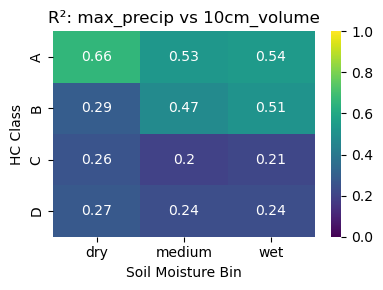

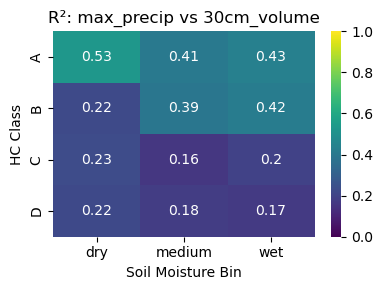


Sample sizes for 10cm_area:

sm_bin        dry   medium      wet
hc_class                           
A           305.0    526.0   1725.0
B          2195.0   1680.0   6810.0
C         27587.0  25517.0  21526.0
D          3608.0   6288.0   3950.0
All           NaN      NaN      NaN

Sample sizes for 30cm_area:

sm_bin        dry   medium      wet
hc_class                           
A           305.0    526.0   1725.0
B          2195.0   1680.0   6810.0
C         27587.0  25517.0  21526.0
D          3608.0   6288.0   3950.0
All           NaN      NaN      NaN

Sample sizes for 10cm_volume:

sm_bin        dry   medium      wet
hc_class                           
A           305.0    526.0   1725.0
B          2195.0   1680.0   6810.0
C         27587.0  25517.0  21526.0
D          3608.0   6288.0   3950.0
All           NaN      NaN      NaN

Sample sizes for 30cm_volume:

sm_bin        dry   medium      wet
hc_class                           
A           305.0    526.0   1725.0
B          2

In [34]:
from scipy.stats import pearsonr, spearmanr
import seaborn as sns

# ---------------------------
# 2. Create global SM bins
# ---------------------------
fixed_edges = pd.qcut(rainfall_events_all_df['mean_sm_2_before_event'], q=3,
    retbins=True, duplicates='drop')[1]

# ---------------------------
# 3. Define HC classes
# ---------------------------
hc_classes = {'A': rainfall_events_all_df_A,
    'B': rainfall_events_all_df_B,
    'C': rainfall_events_all_df_C,
    'D': rainfall_events_all_df_D}

metrics = ['10cm_area', '30cm_area', '10cm_volume', '30cm_volume']
results = []

# ---------------------------
# 4. HC × SM correlations
# ---------------------------
for hc_label, df in hc_classes.items():
    
    df = add_sm_bin(df, fixed_edges=fixed_edges)
    
    for sm_bin in ['dry', 'medium', 'wet']:
        sub = df[df['sm_bin'] == sm_bin].dropna(subset=['max_precip'])
        
        for metric in metrics:
            valid = sub.dropna(subset=[metric])
            
            if len(valid) < 5:
                r, rho, r2, n = np.nan, np.nan, np.nan, len(valid)
            else:
                r, _ = pearsonr(valid['max_precip'], valid[metric])
                rho, _ = spearmanr(valid['max_precip'], valid[metric])
                r2 = r**2
                n = len(valid)
            
            results.append({
                'hc_class': hc_label,
                'sm_bin': sm_bin,
                'metric': metric,
                'pearson_r': r,
                'r2': r2,
                'spearman_rho': rho,
                'n': n})


# ---------------------------
# 5. Overall (ALL HC) correlations
# ---------------------------
# df_all = add_sm_bin(rainfall_events_all_df, fixed_edges=fixed_edges)

# for sm_bin in ['dry', 'medium', 'wet']:
#     sub = df_all[df_all['sm_bin'] == sm_bin].dropna(subset=['max_precip'])
    
#     for metric in metrics:
#         valid = sub.dropna(subset=[metric])
        
#         if len(valid) < 5:
#             r, rho, r2, n = np.nan, np.nan, np.nan, len(valid)
#         else:
#             r, _ = pearsonr(valid['max_precip'], valid[metric])
#             rho, _ = spearmanr(valid['max_precip'], valid[metric])
#             r2 = r**2
#             n = len(valid)
        
#         results.append({
#             'hc_class': 'All',   # 👈 pooled result
#             'sm_bin': sm_bin,
#             'metric': metric,
#             'pearson_r': r,
#             'r2': r2,
#             'spearman_rho': rho,
#             'n': n
#         })


# ---------------------------
# 6. Create results DataFrame
# ---------------------------
corr_df = pd.DataFrame(results)


# ---------------------------
# 7. Plot heatmaps (R²)
# ---------------------------
for metric in metrics:
    
    pivot = corr_df[corr_df['metric'] == metric].pivot(index='hc_class',columns='sm_bin',values='r2')
    # enforce consistent column order
    pivot = pivot[['dry', 'medium', 'wet']]
    
    # optional: enforce row order
    pivot = pivot.reindex(['A', 'B', 'C', 'D'])
    
    plt.figure(figsize=(4, 3))
    sns.heatmap(pivot,annot=True,cmap='viridis',vmin=0,vmax=1)
    
    plt.title(f'R²: max_precip vs {metric}')
    plt.ylabel('HC Class')
    plt.xlabel('Soil Moisture Bin')
    plt.tight_layout()
    plt.show()


# ---------------------------
# 8. (Optional) Check sample sizes
# ---------------------------
for metric in metrics:
    pivot_n = corr_df[corr_df['metric'] == metric].pivot(
        index='hc_class',
        columns='sm_bin',
        values='n')
    pivot_n = pivot_n[['dry', 'medium', 'wet']]
    pivot_n = pivot_n.reindex(['A', 'B', 'C', 'D', 'All'])
    
    print(f"\nSample sizes for {metric}:\n")
    print(pivot_n)

In [35]:
# import statsmodels.formula.api as smf

# df_all = pd.concat([df.assign(hc_class=label) for label, df in hc_classes.items()])
# model = smf.ols('Q("10cm_area") ~ max_precip * mean_sm_2_before_event * C(hc_class)', data=df_all).fit()
# print(model.summary())

</div>

<div style="background-color: #f0faf0; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Show the mean flood response as a joint function of rainfall AND soil moisture, binned)
      

</div>

/tmp/ipykernel_1864900/3814591689.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(['precip_bin', 'sm_bin'])[flood_metric].mean().unstack()
/tmp/ipykernel_1864900/3814591689.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(['precip_bin', 'sm_bin'])[flood_metric].mean().unstack()
/tmp/ipykernel_1864900/3814591689.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = 

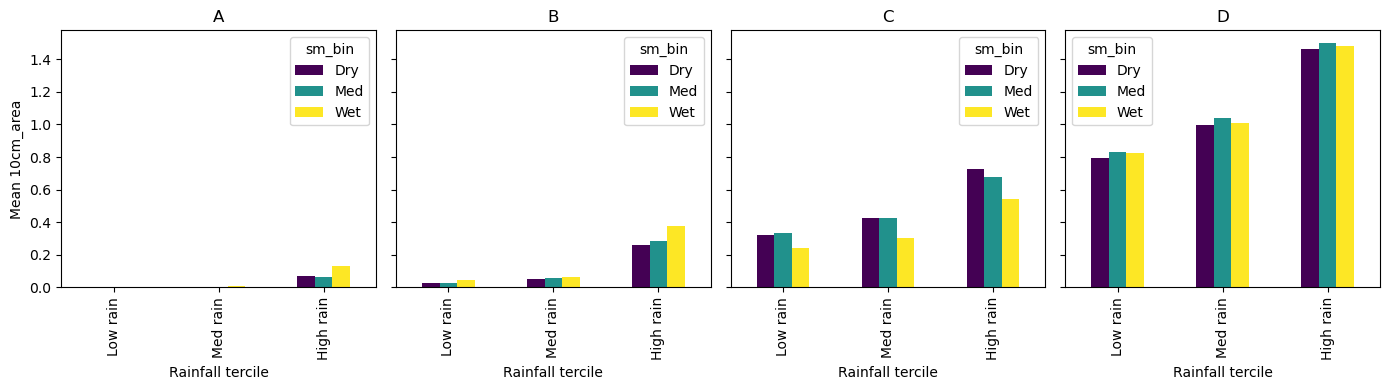

In [36]:
def plot_binned_sm_effect(df, flood_metric, hc_label, ax):
    df = df[['max_precip', 'mean_sm_2_before_event', flood_metric]].dropna()
    
    # Bin both rainfall and SM into terciles
    df['precip_bin'] = pd.qcut(df['max_precip'], 3, labels=['Low rain', 'Med rain', 'High rain'])
    df['sm_bin'] = pd.qcut(df['mean_sm_2_before_event'], 3, labels=['Dry', 'Med', 'Wet'])
    
    grouped = df.groupby(['precip_bin', 'sm_bin'])[flood_metric].mean().unstack()
    grouped.plot(kind='bar', ax=ax, colormap='viridis')
    ax.set_title(f'{hc_label}')
    ax.set_xlabel('Rainfall tercile')
    ax.set_ylabel(f'Mean {flood_metric}')

fig, axs = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
for ax, (hc_label, hc_df) in zip(axs, hc_groups.items()):
    plot_binned_sm_effect(hc_df, '10cm_area', hc_label, ax)
fig.tight_layout()

</div>

<div style="background-color: #f0faf0; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Explore the partial R2 - for just high/med/low HC events

</div>

In [37]:

def partial_r2_for_catchment(df_catch, flood_metric='10cm_area'):
    """
    Returns incremental R² of soil moisture features beyond rainfall + storm shape.
    """
    # Drop rows with nulls in relevant columns
    sm_cols = ['mean_sm_2_before_event']
    
    base_features = ['max_precip'] #' total_acc']
    
    all_cols = base_features + sm_cols + [flood_metric]
    df = df_catch[all_cols].dropna()
    
    if len(df) < 20:  # skip catchments with too few events
        return np.nan
    
    X_base = df[base_features].values
    X_full = df[base_features + sm_cols].values
    y = df[flood_metric].values
    
    # Standardise
    scaler_base = StandardScaler()
    scaler_full = StandardScaler()
    X_base_s = scaler_base.fit_transform(X_base)
    X_full_s = scaler_full.fit_transform(X_full)
    
    r2_base = r2_score(y, LinearRegression().fit(X_base_s, y).predict(X_base_s))
    r2_full = r2_score(y, LinearRegression().fit(X_full_s, y).predict(X_full_s))
    
    return r2_base, r2_full, max(r2_full - r2_base, 0)  # clip at 0; negative = SM adds nothing

/tmp/ipykernel_1864900/2321452266.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for catch_id, group in rainfall_events_all_df.groupby('HC_status'):


,HC_status,sm_sensitivity,r2_base,r2_full,hc_median,n_events,x_coord,y_coord
0,D,0.000006,0.191989,0.191995,0.098380,13847,467500.0,232500.0
1,C,0.023008,0.144722,0.167730,0.364253,74955,312500.0,357500.0
2,B,0.000076,0.581518,0.581594,2.036644,10688,212500.0,802500.0
3,A,0.004509,0.591215,0.595724,3.648397,2556,197500.0,797500.0


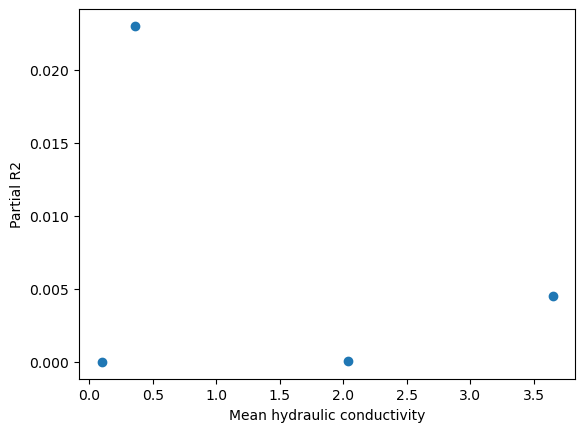

In [38]:
# Apply across catchments
results = []
for catch_id, group in rainfall_events_all_df.groupby('HC_status'):
    r2_base, r2_full, score = partial_r2_for_catchment(group, flood_metric='10cm_area')
    hc_median = group['hc_at_peak'].median()
    results.append({'HC_status': catch_id,'sm_sensitivity': score,
                    'r2_base': r2_base, 'r2_full': r2_full,
                    'hc_median': hc_median,'n_events': len(group),
        'x_coord': group['x_coord'].median(),'y_coord': group['y_coord'].median(),})

results_df = pd.DataFrame(results)
plt.scatter(results_df['hc_median'], results_df['sm_sensitivity'])
plt.xlabel('Mean hydraulic conductivity')
plt.ylabel('Partial R2')
results_df